# Loading the dataset

In [6]:
import pandas as pd

file_path = "../data/electricity_dah_prices.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

Shape: (8761, 8)

Columns:
['date', 'hour', 'france', 'italy', 'belgium', 'spain', 'uk', 'germany']

First 5 rows:
         date           hour  france   italy  belgium   spain    uk  germany
0  2022/01/01  00:00 - 01:00   89.06  170.28    82.02  145.86  0.27    50.05
1  2022/01/01  01:00 - 02:00   78.48  155.72    67.07  114.90 -0.01    41.33
2  2022/01/01  02:00 - 03:00   85.16  147.09    75.11  113.87  0.27    43.22
3  2022/01/01  03:00 - 04:00   50.00   91.00    50.91   97.80 -0.01    45.46
4  2022/01/01  04:00 - 05:00   37.67  104.00    37.67   97.80 -0.01    37.67


# Column inspection

In [7]:
print("\nData types before parsing:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum())


Data types before parsing:
date        object
hour        object
france     float64
italy      float64
belgium    float64
spain      float64
uk         float64
germany    float64
dtype: object

Missing values per column:
date          0
hour          0
france        1
italy         1
belgium       1
spain         1
uk         1442
germany       1
dtype: int64


# Selecting france as the initial country, then cleaning the code into correct formats

In [8]:
chosen_country = "france"

# Building a proper timestamp

df["hour_start"] = df["hour"].str.split(" - ").str[0]

# Combining date + starting hour
df["timestamp"] = pd.to_datetime(
    df["date"] + " " + df["hour_start"],
    format="%Y/%m/%d %H:%M",
    errors="coerce"
)

# Keeping only the chosen series
data = df[["timestamp", chosen_country]].copy()
data = data.rename(columns={chosen_country: "price"})


# Checking dataset till now 

In [9]:
print("First 5 rows:")
print(data.head())
print("\nData types:")
print(data.dtypes)
print("\nMissing values:")
print(data.isna().sum())

First 5 rows:
            timestamp  price
0 2022-01-01 00:00:00  89.06
1 2022-01-01 01:00:00  78.48
2 2022-01-01 02:00:00  85.16
3 2022-01-01 03:00:00  50.00
4 2022-01-01 04:00:00  37.67

Data types:
timestamp    datetime64[ns]
price               float64
dtype: object

Missing values:
timestamp    0
price        1
dtype: int64


# Checking missing entries or duplicate entries

In [10]:
bad_timestamps = data["timestamp"].isna().sum()
print(f"\nBad timestamps: {bad_timestamps}")

missing_prices = data["price"].isna().sum()
print(f"Missing prices: {missing_prices}")

# Sort
data = data.sort_values("timestamp").reset_index(drop=True)

# Duplicate timestamps
duplicate_timestamps = data.duplicated(subset=["timestamp"]).sum()
print(f"Duplicate timestamps: {duplicate_timestamps}")

# Time difference check
time_diffs = data["timestamp"].diff().dropna()
print("\nMost common time differences:")
print(time_diffs.value_counts().head(10))

# Check hourly continuity
expected_freq = pd.Timedelta(hours=1)
non_hourly_steps = (time_diffs != expected_freq).sum()
print(f"\nNon-hourly steps: {non_hourly_steps}")

# Missing hourly timestamps
full_range = pd.date_range(
    start=data["timestamp"].min(),
    end=data["timestamp"].max(),
    freq="h"
)
missing_timestamps = full_range.difference(data["timestamp"])
print(f"Missing hourly timestamps: {len(missing_timestamps)}")

if len(missing_timestamps) > 0:
    print("\nFirst 10 missing timestamps:")
    print(missing_timestamps[:10])


Bad timestamps: 0
Missing prices: 1
Duplicate timestamps: 1

Most common time differences:
timestamp
0 days 01:00:00    8759
0 days 00:00:00       1
Name: count, dtype: int64

Non-hourly steps: 1
Missing hourly timestamps: 0


# Final summary

In [11]:

print(" STEP 1 FINAL SUMMARY \n")
print("Dataset file name:", file_path)
print("Timestamp columns used: date + hour")
print("Chosen country:", chosen_country)
print("Final price column: price")
print("Timestamps parsed cleanly:", bad_timestamps == 0)
print("Duplicate timestamps:", duplicate_timestamps)
print("Missing hourly timestamps:", len(missing_timestamps))
print("Missing prices:", missing_prices)

 STEP 1 FINAL SUMMARY 

Dataset file name: ../data/electricity_dah_prices.csv
Timestamp columns used: date + hour
Chosen country: france
Final price column: price
Timestamps parsed cleanly: True
Duplicate timestamps: 1
Missing hourly timestamps: 0
Missing prices: 1


# Creating a single clean time-series table

In [12]:
df = pd.read_csv(file_path)

# Building timestamp from date + start hour
df["hour_start"] = df["hour"].str.split(" - ").str[0]
df["timestamp"] = pd.to_datetime(
    df["date"] + " " + df["hour_start"],
    format="%Y/%m/%d %H:%M",
    errors="coerce"
)

# Keeping only what we need
data = df[["timestamp", chosen_country]].copy()
data = data.rename(columns={chosen_country: "price"})

# Dropping bad timestamps
data = data.dropna(subset=["timestamp"]).copy()

# Sorting by time
data = data.sort_values("timestamp").reset_index(drop=True)

# Checking duplicates
dup_count = data.duplicated(subset=["timestamp"]).sum()
print("Duplicate timestamps before removal:", dup_count)

if dup_count > 0:
    data = data.drop_duplicates(subset=["timestamp"], keep="first").reset_index(drop=True)

print("Shape after duplicate removal:", data.shape)

# Checking missing prices
print("\nMissing prices before handling:", data["price"].isna().sum())

missing_rows = data[data["price"].isna()]
print("\nRows with missing price:")
print(missing_rows)

# using time interpolation as only 1 missing value for price exsists
data["price"] = data["price"].interpolate(method="linear")

print("\nMissing prices after interpolation:", data["price"].isna().sum())

Duplicate timestamps before removal: 1
Shape after duplicate removal: (8760, 2)

Missing prices before handling: 1

Rows with missing price:
               timestamp  price
2042 2022-03-27 02:00:00    NaN

Missing prices after interpolation: 0


# Final checks

In [13]:
print("\nData types:")
print(data.dtypes)

print("\nFirst 5 rows:")
print(data.head())

print("\nLast 5 rows:")
print(data.tail())

# Check full hourly continuity
full_range = pd.date_range(
    start=data["timestamp"].min(),
    end=data["timestamp"].max(),
    freq="h"
)
missing_timestamps = full_range.difference(data["timestamp"])

print("\nMissing hourly timestamps:", len(missing_timestamps))
if len(missing_timestamps) > 0:
    print(missing_timestamps[:10])

# Save cleaned series
output_file = f"clean_{chosen_country}_prices.csv"
data.to_csv(output_file, index=False)

print("\nSaved cleaned file as:", output_file)

print("\n===== STEP 2 SUMMARY =====")
print("Chosen country:", chosen_country)
print("Final shape:", data.shape)
print("Missing prices remaining:", data['price'].isna().sum())
print("Missing timestamps:", len(missing_timestamps))
print("Date range:", data['timestamp'].min(), "to", data['timestamp'].max())


Data types:
timestamp    datetime64[ns]
price               float64
dtype: object

First 5 rows:
            timestamp  price
0 2022-01-01 00:00:00  89.06
1 2022-01-01 01:00:00  78.48
2 2022-01-01 02:00:00  85.16
3 2022-01-01 03:00:00  50.00
4 2022-01-01 04:00:00  37.67

Last 5 rows:
               timestamp  price
8755 2022-12-31 19:00:00  18.11
8756 2022-12-31 20:00:00   7.60
8757 2022-12-31 21:00:00   3.69
8758 2022-12-31 22:00:00   1.88
8759 2022-12-31 23:00:00   0.10

Missing hourly timestamps: 0

Saved cleaned file as: clean_france_prices.csv

===== STEP 2 SUMMARY =====
Chosen country: france
Final shape: (8760, 2)
Missing prices remaining: 0
Missing timestamps: 0
Date range: 2022-01-01 00:00:00 to 2022-12-31 23:00:00


# Plotting and visualising the new data

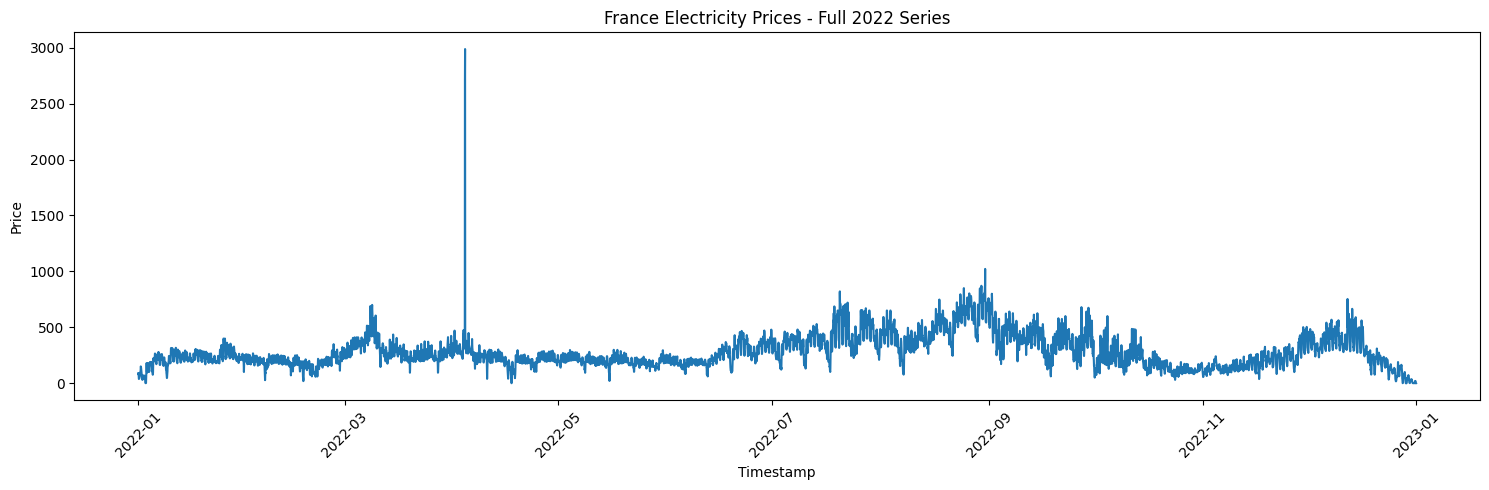

In [14]:
import matplotlib.pyplot as plt

data["timestamp"] = pd.to_datetime(data["timestamp"])
data = data.sort_values("timestamp").reset_index(drop=True)

plt.figure(figsize=(15, 5))
plt.plot(data["timestamp"], data["price"])
plt.title("France Electricity Prices - Full 2022 Series")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Plotting short windows 

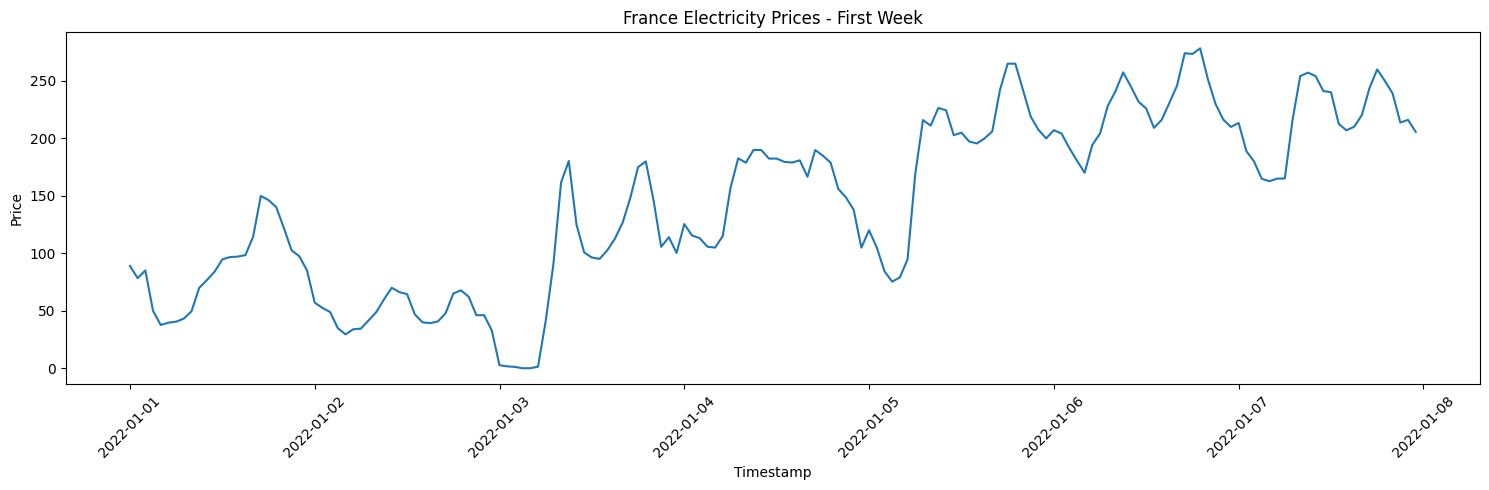

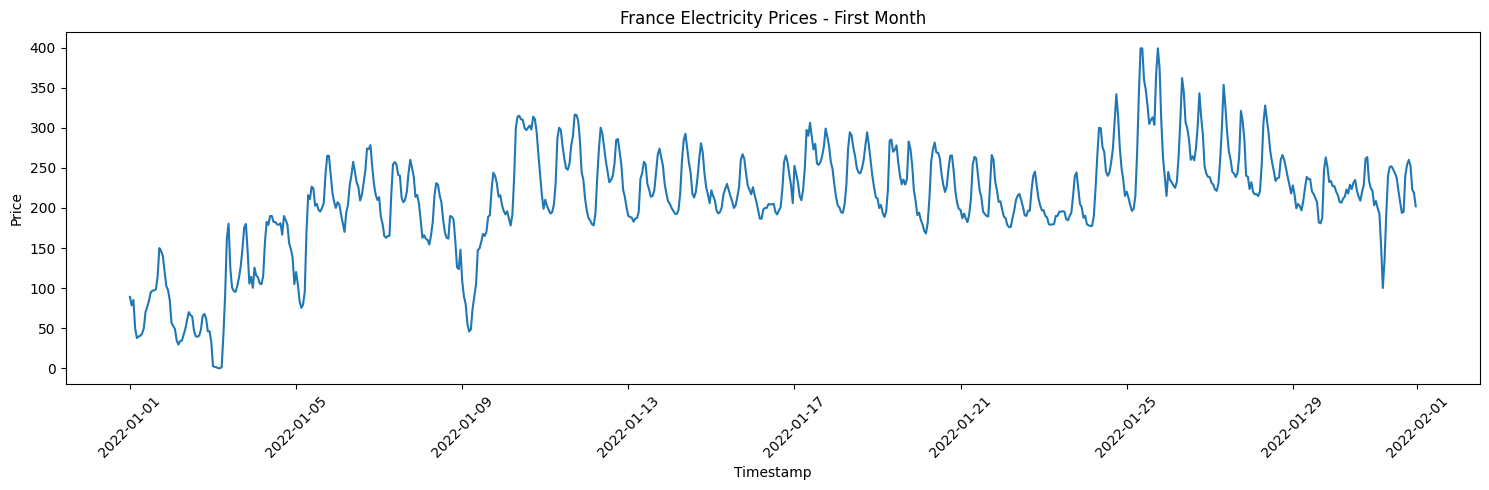

In [15]:
one_week = data[(data["timestamp"] >= "2022-01-01") & (data["timestamp"] < "2022-01-08")]
one_month = data[(data["timestamp"] >= "2022-01-01") & (data["timestamp"] < "2022-02-01")]

plt.figure(figsize=(15, 5))
plt.plot(one_week["timestamp"], one_week["price"])
plt.title("France Electricity Prices - First Week")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
plt.plot(one_month["timestamp"], one_month["price"])
plt.title("France Electricity Prices - First Month")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Stats for the data

In [16]:

print(data["price"].describe())

print("\nMean:", data["price"].mean())
print("Median:", data["price"].median())
print("Std:", data["price"].std())
print("Min:", data["price"].min())
print("Max:", data["price"].max())

count    8760.000000
mean      275.891875
std       145.814945
min        -1.440000
25%       183.062500
50%       239.335000
75%       350.000000
max      2987.780000
Name: price, dtype: float64

Mean: 275.891875
Median: 239.335
Std: 145.81494527267645
Min: -1.44
Max: 2987.78


# Negative Prices checking as the above result has min lower than 0

In [17]:
negative_count = (data["price"] < 0).sum()
print("\nNegative price count:", negative_count)

if negative_count > 0:
    print("\nFirst few negative-price rows:")
    print(data[data["price"] < 0].head())


Negative price count: 4

First few negative-price rows:
               timestamp  price
8690 2022-12-29 02:00:00  -0.05
8691 2022-12-29 03:00:00  -1.44
8692 2022-12-29 04:00:00  -1.18
8693 2022-12-29 05:00:00  -0.04


# Time based column creation and plotting average hourly prices

Avg price by hour:
    hour       price
0      0  255.225068
1      1  236.667589
2      2  230.119795
3      3  216.246712
4      4  213.190110
5      5  228.008630
6      6  265.549315
7      7  305.819178
8      8  320.451973
9      9  306.128027
10    10  285.666000
11    11  279.661123
12    12  276.190192
13    13  260.450740
14    14  260.054932
15    15  258.124740
16    16  263.634274
17    17  293.000438
18    18  322.624137
19    19  345.633233
20    20  330.443205
21    21  303.359014
22    22  291.198795
23    23  273.957781


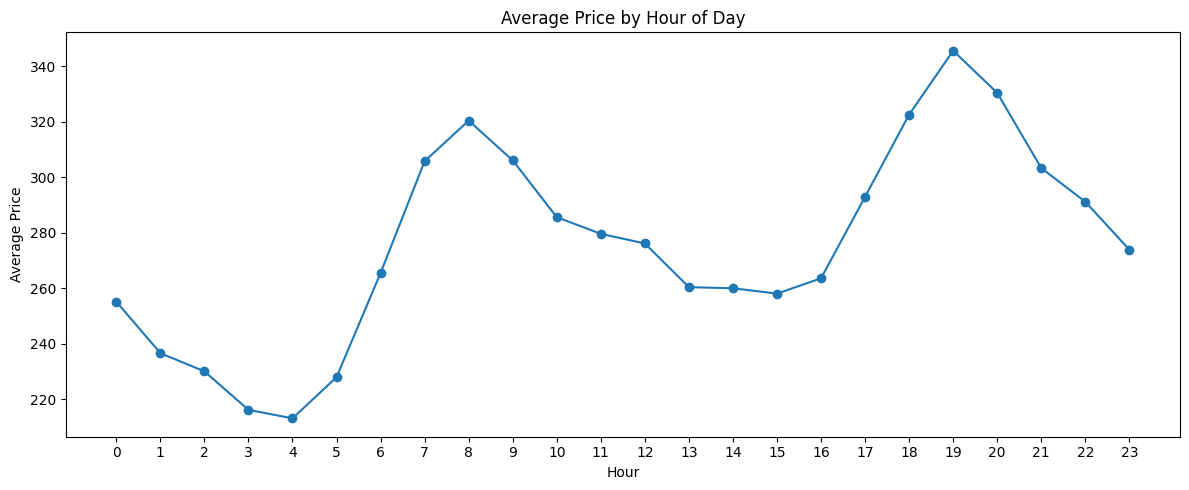

In [20]:
data["hour"] = data["timestamp"].dt.hour
data["day_name"] = data["timestamp"].dt.day_name()
data["month"] = data["timestamp"].dt.month
data["month_name"] = data["timestamp"].dt.month_name()


avg_by_hour = data.groupby("hour", as_index=False)["price"].mean()

print("Avg price by hour:")
print(avg_by_hour)

plt.figure(figsize=(12, 5))
plt.plot(avg_by_hour["hour"], avg_by_hour["price"], marker="o")
plt.title("Average Price by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Price")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

# Avg price by day of the week


Avg price by day of week:
    day_name       price
1     Monday  284.349014
5    Tuesday  303.750865
6  Wednesday  301.496875
4   Thursday  296.892420
0     Friday  291.278229
2   Saturday  240.952956
3     Sunday  213.194667


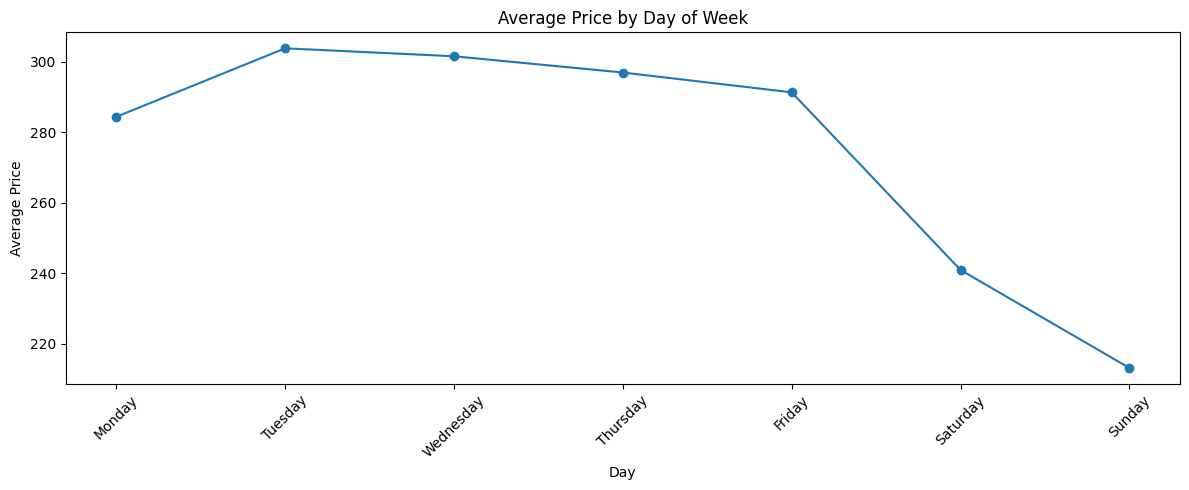

In [22]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

avg_by_weekday = (
    data.groupby("day_name", as_index=False)["price"]
    .mean()
)
avg_by_weekday["day_name"] = pd.Categorical(
    avg_by_weekday["day_name"],
    categories=weekday_order,
    ordered=True
)
avg_by_weekday = avg_by_weekday.sort_values("day_name")

print("\nAvg price by day of week:")
print(avg_by_weekday)

plt.figure(figsize=(12, 5))
plt.plot(avg_by_weekday["day_name"], avg_by_weekday["price"], marker="o")
plt.title("Average Price by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Avg price by month


Avg price by month:
   month_name       price
4     January  211.422876
3    February  185.549226
7       March  295.101095
0       April  233.095931
8         May  197.430806
6        June  248.400153
5        July  400.866344
1      August  492.488777
11  September  394.703278
10    October  178.987177
9    November  191.882681
2    December  270.886626


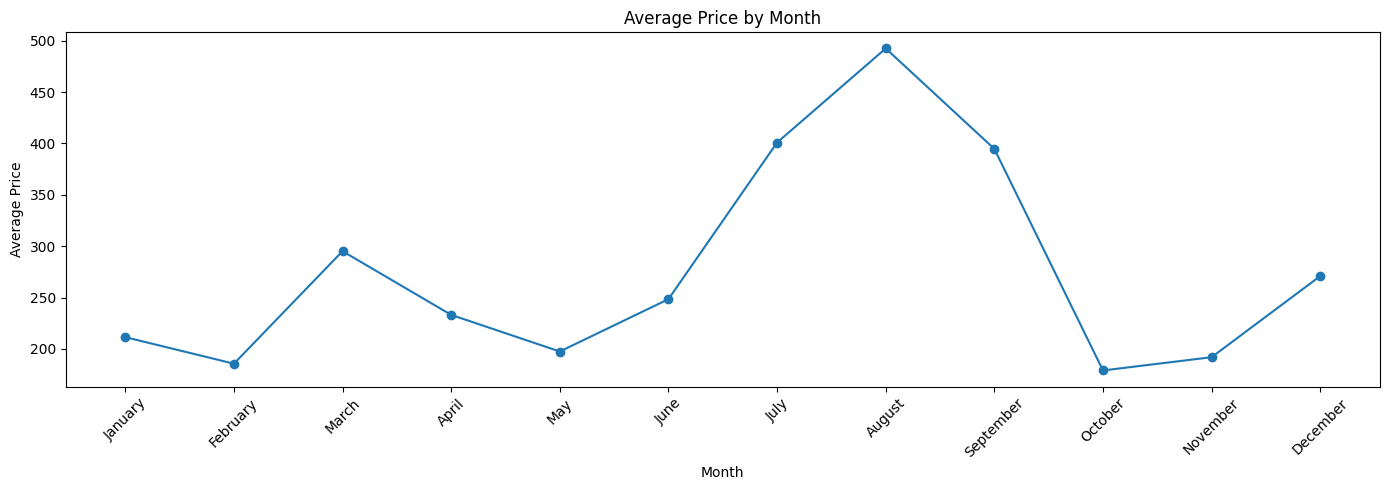

In [23]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

avg_by_month = (
    data.groupby("month_name", as_index=False)["price"]
    .mean()
)
avg_by_month["month_name"] = pd.Categorical(
    avg_by_month["month_name"],
    categories=month_order,
    ordered=True
)
avg_by_month = avg_by_month.sort_values("month_name")

print("\nAvg price by month:")
print(avg_by_month)

plt.figure(figsize=(14, 5))
plt.plot(avg_by_month["month_name"], avg_by_month["price"], marker="o")
plt.title("Average Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Results summary

In [24]:
highest_hour = avg_by_hour.loc[avg_by_hour["price"].idxmax()]
lowest_hour = avg_by_hour.loc[avg_by_hour["price"].idxmin()]
highest_month = avg_by_month.loc[avg_by_month["price"].idxmax()]
lowest_month = avg_by_month.loc[avg_by_month["price"].idxmin()]
print(f"Highest average hour: {int(highest_hour['hour'])}:00 with avg price {highest_hour['price']:.2f}")
print(f"Lowest average hour: {int(lowest_hour['hour'])}:00 with avg price {lowest_hour['price']:.2f}")
print(f"Highest average month: {highest_month['month_name']} with avg price {highest_month['price']:.2f}")
print(f"Lowest average month: {lowest_month['month_name']} with avg price {lowest_month['price']:.2f}")
print(f"Negative prices present: {'Yes' if negative_count > 0 else 'No'}")

Highest average hour: 19:00 with avg price 345.63
Lowest average hour: 4:00 with avg price 213.19
Highest average month: August with avg price 492.49
Lowest average month: October with avg price 178.99
Negative prices present: Yes


# Now we create the model dataframe with time based features and lag features

In [25]:
features_df = data.copy()

# Time features
features_df["hour"] = features_df["timestamp"].dt.hour
features_df["day_of_week"] = features_df["timestamp"].dt.dayofweek   # Monday=0
features_df["month"] = features_df["timestamp"].dt.month
features_df["is_weekend"] = features_df["day_of_week"].isin([5, 6]).astype(int)

# Lag features
features_df["lag_1"] = features_df["price"].shift(1)
features_df["lag_24"] = features_df["price"].shift(24)
features_df["lag_168"] = features_df["price"].shift(168)

# Rolling features using only past data
past_price = features_df["price"].shift(1)

features_df["rolling_mean_24"] = past_price.rolling(window=24).mean()
features_df["rolling_std_24"] = past_price.rolling(window=24).std()

features_df["rolling_mean_168"] = past_price.rolling(window=168).mean()
features_df["rolling_std_168"] = past_price.rolling(window=168).std()

# Target: next hour price
features_df["target_t_plus_1"] = features_df["price"].shift(-1)

# Drop rows made invalid by lags/rolling/target
model_df = features_df.dropna().reset_index(drop=True)


# Final stats of the model df

In [26]:
print("Model dataframe shape:", model_df.shape)
print("\nColumns:")
print(model_df.columns.tolist())

print("\nFirst 5 rows:")
print(model_df.head())

print("\nMissing values per column:")
print(model_df.isna().sum())

print("\nDate range:")
print(model_df["timestamp"].min(), "to", model_df["timestamp"].max())

Model dataframe shape: (8591, 16)

Columns:
['timestamp', 'price', 'hour', 'day_name', 'month', 'month_name', 'day_of_week', 'is_weekend', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_std_24', 'rolling_mean_168', 'rolling_std_168', 'target_t_plus_1']

First 5 rows:
            timestamp   price  hour  day_name  month month_name  day_of_week  \
0 2022-01-08 00:00:00  184.96     0  Saturday      1    January            5   
1 2022-01-08 01:00:00  162.79     1  Saturday      1    January            5   
2 2022-01-08 02:00:00  166.00     2  Saturday      1    January            5   
3 2022-01-08 03:00:00  161.63     3  Saturday      1    January            5   
4 2022-01-08 04:00:00  160.00     4  Saturday      1    January            5   

   is_weekend   lag_1  lag_24  lag_168  rolling_mean_24  rolling_std_24  \
0           1  205.74  213.47    89.06       215.915000       31.723475   
1           1  184.96  189.00    78.48       214.727083       32.346682   
2           1  

# Now we split the data into test and train for the model

In [27]:
feature_cols = [
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_mean_24",
    "rolling_std_24",
    "rolling_mean_168",
    "rolling_std_168",
]

target_col = "target_t_plus_1"

split_1 = int(len(model_df) * 0.70)
split_2 = int(len(model_df) * 0.85)

train_df = model_df.iloc[:split_1].copy()
val_df = model_df.iloc[split_1:split_2].copy()
test_df = model_df.iloc[split_2:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("\nTrain date range:", train_df["timestamp"].min(), "to", train_df["timestamp"].max())
print("Validation date range:", val_df["timestamp"].min(), "to", val_df["timestamp"].max())
print("Test date range:", test_df["timestamp"].min(), "to", test_df["timestamp"].max())

print("\nFeature columns used:")
print(feature_cols)

Train shape: (6013, 11) (6013,)
Validation shape: (1289, 11) (1289,)
Test shape: (1289, 11) (1289,)

Train date range: 2022-01-08 00:00:00 to 2022-09-15 12:00:00
Validation date range: 2022-09-15 13:00:00 to 2022-11-08 05:00:00
Test date range: 2022-11-08 06:00:00 to 2022-12-31 22:00:00

Feature columns used:
['hour', 'day_of_week', 'month', 'is_weekend', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_std_24', 'rolling_mean_168', 'rolling_std_168']


# Now we perform three baseline tasks as a benchmark which our model must beat:
- per hour 
- per day
- per week

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


baseline_results = []

baseline_defs = {
    "naive_lag_1": "lag_1",
    "seasonal_naive_lag_24": "lag_24",
    "seasonal_naive_lag_168": "lag_168",
}

for model_name, pred_col in baseline_defs.items():
    y_pred = val_df[pred_col]
    
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    
    baseline_results.append({
        "model": model_name,
        "prediction_source": pred_col,
        "MAE": mae,
        "RMSE": rmse
    })

baseline_results_df = pd.DataFrame(baseline_results).sort_values("MAE").reset_index(drop=True)

print("validation baseline results:")
print(baseline_results_df)

validation baseline results:
                    model prediction_source        MAE        RMSE
0             naive_lag_1             lag_1  44.340147   63.575572
1   seasonal_naive_lag_24            lag_24  59.663018   85.901305
2  seasonal_naive_lag_168           lag_168  77.537580  101.776091


# visualising the baselines

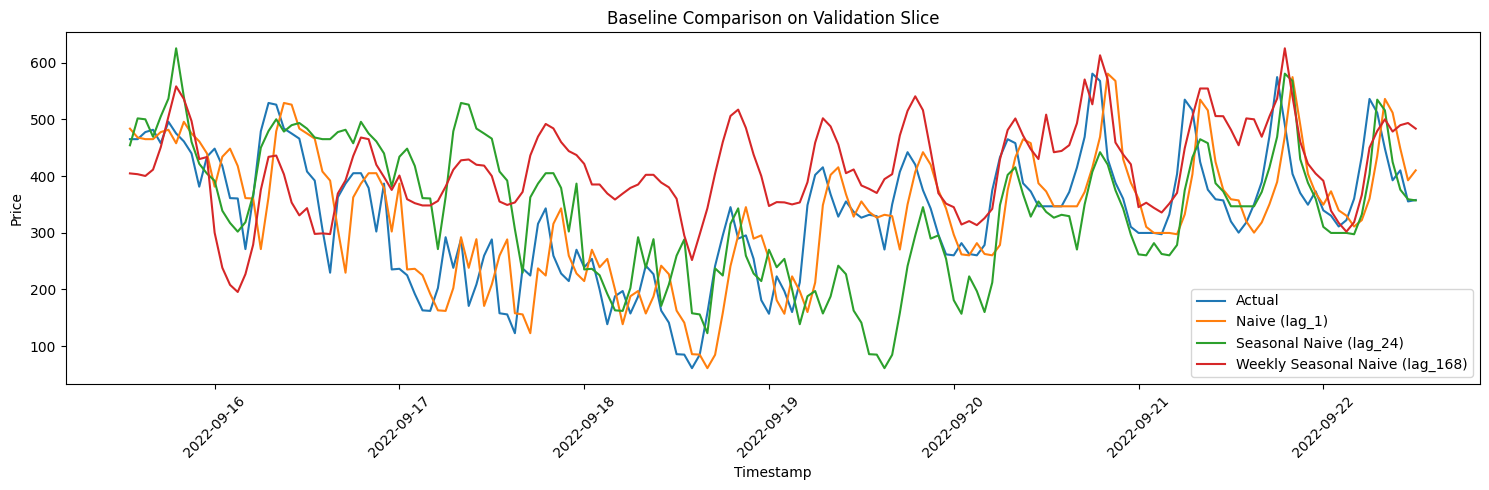

In [29]:
plot_df = val_df[["timestamp", "target_t_plus_1", "lag_1", "lag_24", "lag_168"]].head(168).copy()

plt.figure(figsize=(15, 5))
plt.plot(plot_df["timestamp"], plot_df["target_t_plus_1"], label="Actual")
plt.plot(plot_df["timestamp"], plot_df["lag_1"], label="Naive (lag_1)")
plt.plot(plot_df["timestamp"], plot_df["lag_24"], label="Seasonal Naive (lag_24)")
plt.plot(plot_df["timestamp"], plot_df["lag_168"], label="Weekly Seasonal Naive (lag_168)")
plt.title("Baseline Comparison on Validation Slice")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

#### As can be seen from the findings above, the naive(lag1) baseline has the least error MAE RMSE respectively 44.340147 and 63.575572. That is the metric we must beat

# So for the final model candidates, we try linear regression first

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

val_pred_lr = lr_model.predict(X_val)

lr_val_mae = mean_absolute_error(y_val, val_pred_lr)
lr_val_rmse = np.sqrt(mean_squared_error(y_val, val_pred_lr))

print("===== LINEAR REGRESSION VALIDATION RESULTS =====")
print("MAE:", lr_val_mae)
print("RMSE:", lr_val_rmse)

===== LINEAR REGRESSION VALIDATION RESULTS =====
MAE: 40.84529164343391
RMSE: 56.44540690421012


In [37]:
baseline_mae = 44.340147
baseline_rmse = 63.575572

print("Comparison vs best baseline: ")
print("Best baseline MAE:", baseline_mae)
print("Linear Regression MAE:", lr_val_mae)
print("MAE improvement:", baseline_mae - lr_val_mae)

print("\nBest baseline RMSE:", baseline_rmse)
print("Linear Regression RMSE:", lr_val_rmse)
print("RMSE improvement:", baseline_rmse - lr_val_rmse)

print("We can see here that the error is lower in linear regression but we still have to look at it visually to see if thats actually the case")

Comparison vs best baseline: 
Best baseline MAE: 44.340147
Linear Regression MAE: 40.84529164343391
MAE improvement: 3.4948553565660916

Best baseline RMSE: 63.575572
Linear Regression RMSE: 56.44540690421012
RMSE improvement: 7.130165095789884
We can see here that the error is lower in linear regression but we still have to look at it visually to see if thats actually the case


# Inspecting predictions visually on a short validation slice:

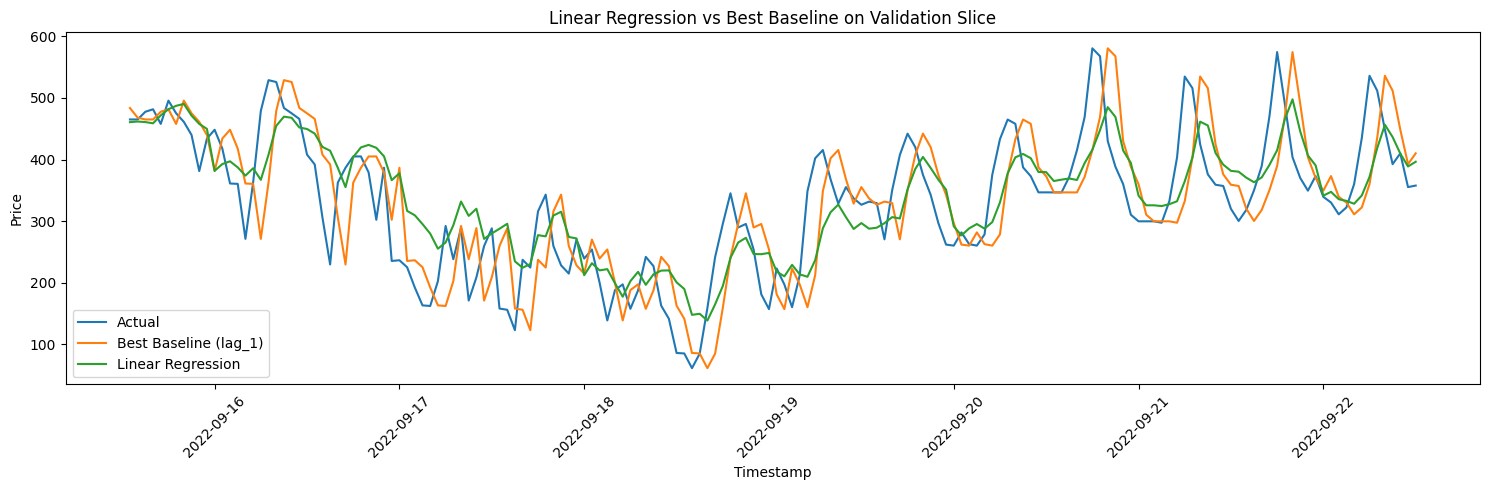

In [35]:
plot_df = val_df[["timestamp", "target_t_plus_1"]].copy()
plot_df["lr_pred"] = val_pred_lr
plot_df["baseline_pred"] = val_df["lag_1"].values

plot_slice = plot_df.head(168)

plt.figure(figsize=(15, 5))
plt.plot(plot_slice["timestamp"], plot_slice["target_t_plus_1"], label="Actual")
plt.plot(plot_slice["timestamp"], plot_slice["baseline_pred"], label="Best Baseline (lag_1)")
plt.plot(plot_slice["timestamp"], plot_slice["lr_pred"], label="Linear Regression")
plt.title("Linear Regression vs Best Baseline on Validation Slice")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Now we introduce a non linear model

In [38]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_iter=300,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42
)

hgb_model.fit(X_train, y_train)

val_pred_hgb = hgb_model.predict(X_val)

hgb_val_mae = mean_absolute_error(y_val, val_pred_hgb)
hgb_val_rmse = np.sqrt(mean_squared_error(y_val, val_pred_hgb))

print("HistgrafientBoostingRegressor validation results:")
print("MAE:", hgb_val_mae)
print("RMSE:", hgb_val_rmse)

HistgrafientBoostingRegressor validation results:
MAE: 33.427344507586504
RMSE: 46.354965308250236


In [39]:
results_compare = pd.DataFrame([
    {"model": "Best Baseline (lag_1)", "MAE": 44.340147, "RMSE": 63.575572},
    {"model": "Linear Regression", "MAE": 40.84529164343391, "RMSE": 56.44540690421012},
    {"model": "HistGradientBoosting", "MAE": hgb_val_mae, "RMSE": hgb_val_rmse},
]).sort_values("MAE").reset_index(drop=True)

print(results_compare)

                   model        MAE       RMSE
0   HistGradientBoosting  33.427345  46.354965
1      Linear Regression  40.845292  56.445407
2  Best Baseline (lag_1)  44.340147  63.575572


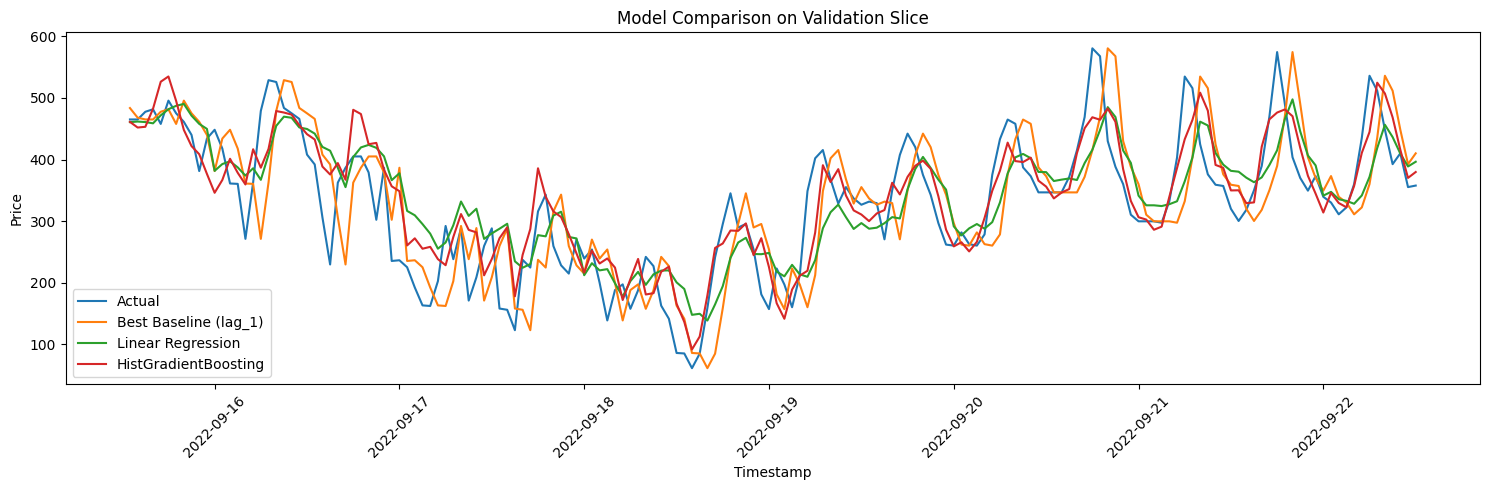

In [40]:
plot_df = val_df[["timestamp", "target_t_plus_1"]].copy()
plot_df["baseline_pred"] = val_df["lag_1"].values
plot_df["lr_pred"] = val_pred_lr
plot_df["hgb_pred"] = val_pred_hgb

plot_slice = plot_df.head(168)

plt.figure(figsize=(15, 5))
plt.plot(plot_slice["timestamp"], plot_slice["target_t_plus_1"], label="Actual")
plt.plot(plot_slice["timestamp"], plot_slice["baseline_pred"], label="Best Baseline (lag_1)")
plt.plot(plot_slice["timestamp"], plot_slice["lr_pred"], label="Linear Regression")
plt.plot(plot_slice["timestamp"], plot_slice["hgb_pred"], label="HistGradientBoosting")
plt.title("Model Comparison on Validation Slice")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

#### Histgradientboosting model is the best one up till now. before moving on though
#### we must check which features are influencing the result the most. 

In [42]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    hgb_model,
    X_val,
    y_val,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

feature_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

print(feature_importance_df)

             feature  importance_mean  importance_std
0    rolling_std_168        70.154876        2.895840
1              lag_1        66.065577        1.134249
2    rolling_mean_24        21.578694        0.735736
3               hour        16.848156        0.692529
4     rolling_std_24        13.507204        0.728155
5   rolling_mean_168         8.906420        0.456752
6        day_of_week         2.236963        0.255276
7             lag_24         2.214554        0.121919
8            lag_168         0.783969        0.129191
9              month         0.000000        0.000000
10        is_weekend         0.000000        0.000000


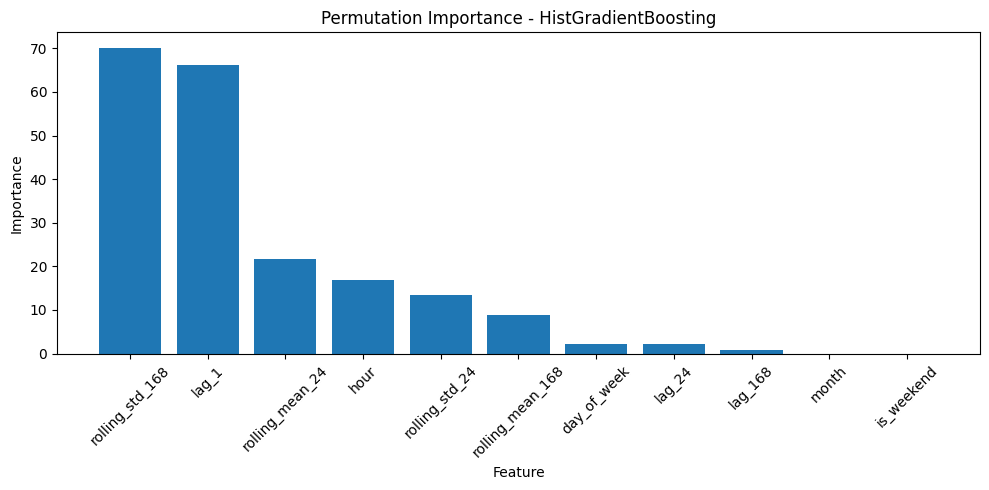

In [43]:
plt.figure(figsize=(10, 5))
plt.bar(feature_importance_df["feature"], feature_importance_df["importance_mean"])
plt.title("Permutation Importance - HistGradientBoosting")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### we can see that features like month and weekend have little to zero impact. and the important features are highlighted clearly

# Running the best baseline model, linear regression model, and hgb model on the test set

In [44]:
# Baseline predictions on test
test_pred_baseline = test_df["lag_1"]

# Linear Regression predictions on test
test_pred_lr = lr_model.predict(X_test)

# HistGradientBoosting predictions on test
test_pred_hgb = hgb_model.predict(X_test)

test_results = pd.DataFrame([
    {
        "model": "Best Baseline (lag_1)",
        "MAE": mean_absolute_error(y_test, test_pred_baseline),
        "RMSE": np.sqrt(mean_squared_error(y_test, test_pred_baseline)),
    },
    {
        "model": "Linear Regression",
        "MAE": mean_absolute_error(y_test, test_pred_lr),
        "RMSE": np.sqrt(mean_squared_error(y_test, test_pred_lr)),
    },
    {
        "model": "HistGradientBoosting",
        "MAE": mean_absolute_error(y_test, test_pred_hgb),
        "RMSE": np.sqrt(mean_squared_error(y_test, test_pred_hgb)),
    },
]).sort_values("MAE").reset_index(drop=True)

print(test_results)

                   model        MAE       RMSE
0  Best Baseline (lag_1)  33.230590  47.790034
1      Linear Regression  36.654774  48.102656
2   HistGradientBoosting  37.498524  50.341898


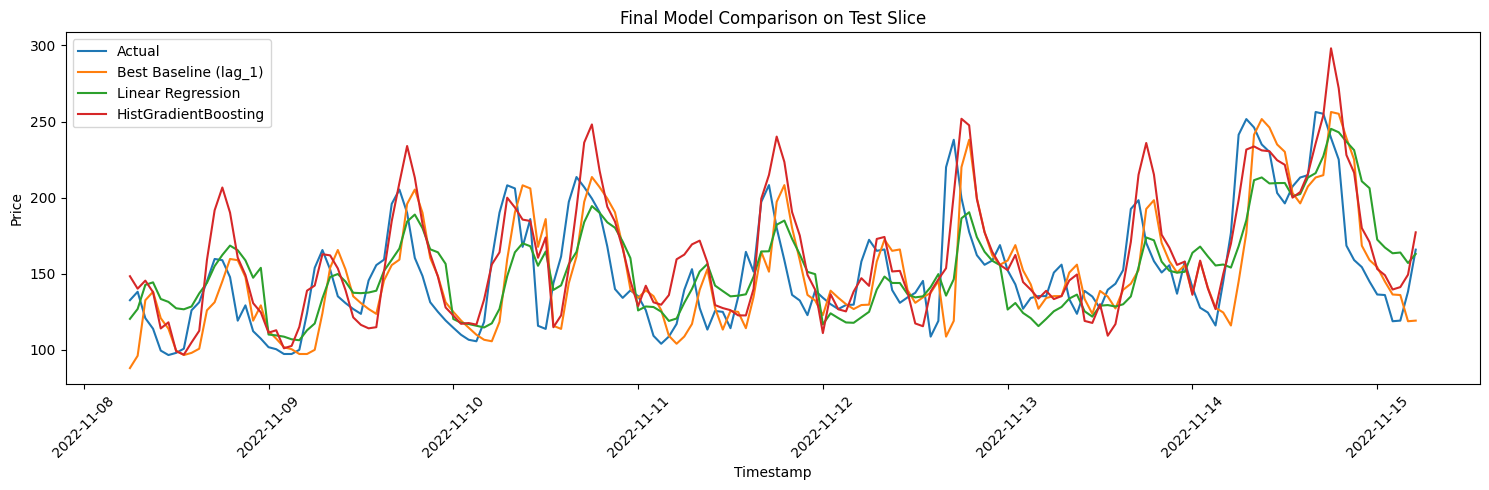

In [45]:
plot_df = test_df[["timestamp", "target_t_plus_1"]].copy()
plot_df["baseline_pred"] = test_pred_baseline.values
plot_df["lr_pred"] = test_pred_lr
plot_df["hgb_pred"] = test_pred_hgb

plot_slice = plot_df.head(168)

plt.figure(figsize=(15, 5))
plt.plot(plot_slice["timestamp"], plot_slice["target_t_plus_1"], label="Actual")
plt.plot(plot_slice["timestamp"], plot_slice["baseline_pred"], label="Best Baseline (lag_1)")
plt.plot(plot_slice["timestamp"], plot_slice["lr_pred"], label="Linear Regression")
plt.plot(plot_slice["timestamp"], plot_slice["hgb_pred"], label="HistGradientBoosting")
plt.title("Final Model Comparison on Test Slice")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

#### The model performances have made a complete u turn on the test set which means hgb is the worst one now and cant be used as the final test. we must now analyse why it happened

In [46]:
split_summary = pd.DataFrame([
    {
        "split": "train",
        "rows": len(train_df),
        "mean_price": train_df["target_t_plus_1"].mean(),
        "std_price": train_df["target_t_plus_1"].std(),
        "min_price": train_df["target_t_plus_1"].min(),
        "max_price": train_df["target_t_plus_1"].max(),
    },
    {
        "split": "validation",
        "rows": len(val_df),
        "mean_price": val_df["target_t_plus_1"].mean(),
        "std_price": val_df["target_t_plus_1"].std(),
        "min_price": val_df["target_t_plus_1"].min(),
        "max_price": val_df["target_t_plus_1"].max(),
    },
    {
        "split": "test",
        "rows": len(test_df),
        "mean_price": test_df["target_t_plus_1"].mean(),
        "std_price": test_df["target_t_plus_1"].std(),
        "min_price": test_df["target_t_plus_1"].min(),
        "max_price": test_df["target_t_plus_1"].max(),
    }
])

print(split_summary)

        split  rows  mean_price   std_price  min_price  max_price
0       train  6013  297.839713  147.622364       0.00    2987.78
1  validation  1289  220.072824  120.741517      29.85     680.00
2        test  1289  246.516106  138.081739      -1.44     753.00


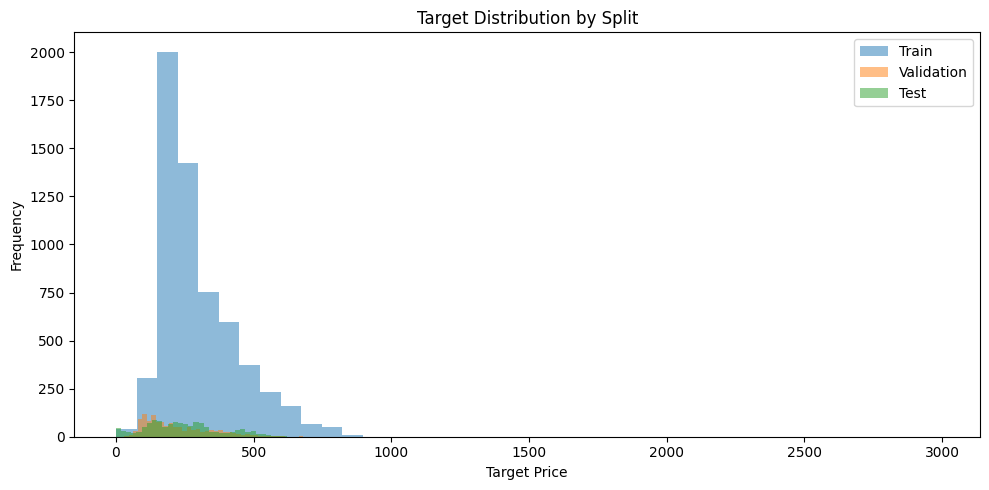

In [47]:
plt.figure(figsize=(10, 5))
plt.hist(train_df["target_t_plus_1"], bins=40, alpha=0.5, label="Train")
plt.hist(val_df["target_t_plus_1"], bins=40, alpha=0.5, label="Validation")
plt.hist(test_df["target_t_plus_1"], bins=40, alpha=0.5, label="Test")
plt.title("Target Distribution by Split")
plt.xlabel("Target Price")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

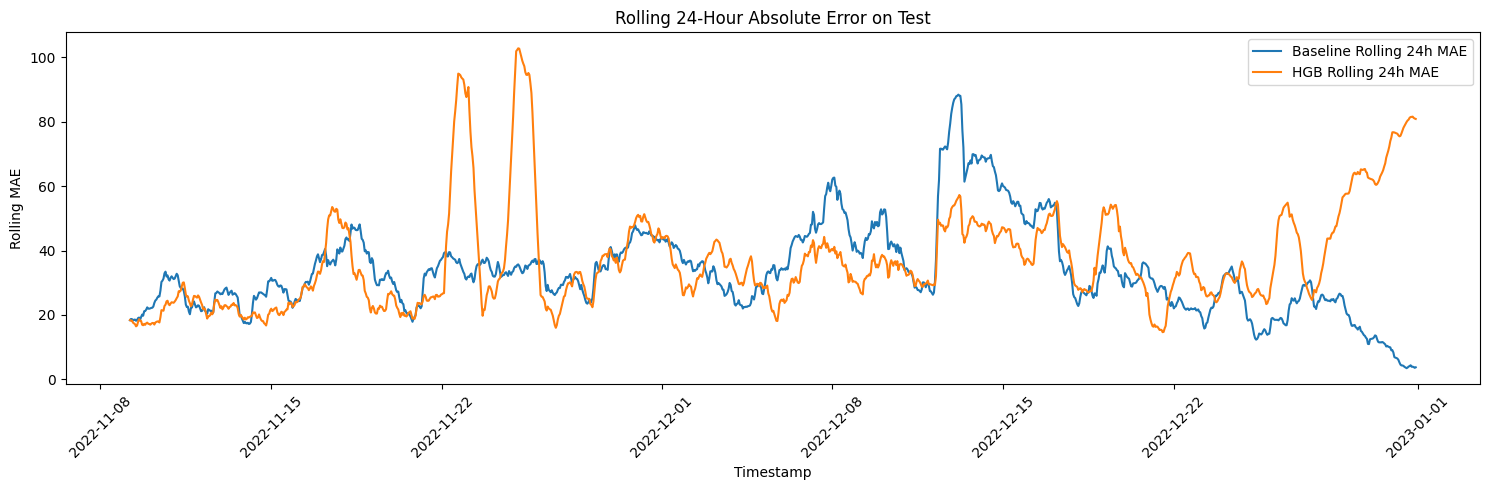

In [48]:
error_df = test_df[["timestamp", "target_t_plus_1"]].copy()
error_df["baseline_pred"] = test_pred_baseline.values
error_df["hgb_pred"] = test_pred_hgb

error_df["baseline_abs_error"] = (error_df["target_t_plus_1"] - error_df["baseline_pred"]).abs()
error_df["hgb_abs_error"] = (error_df["target_t_plus_1"] - error_df["hgb_pred"]).abs()

error_df["baseline_roll_mae_24"] = error_df["baseline_abs_error"].rolling(24).mean()
error_df["hgb_roll_mae_24"] = error_df["hgb_abs_error"].rolling(24).mean()

plt.figure(figsize=(15, 5))
plt.plot(error_df["timestamp"], error_df["baseline_roll_mae_24"], label="Baseline Rolling 24h MAE")
plt.plot(error_df["timestamp"], error_df["hgb_roll_mae_24"], label="HGB Rolling 24h MAE")
plt.title("Rolling 24-Hour Absolute Error on Test")
plt.xlabel("Timestamp")
plt.ylabel("Rolling MAE")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### From the above results we can conclude that the test set was very different from the train set, and the validation set was more towards the train set. we have to take some new steps as told below

# walk-forward backtesting on the three models
### steps to be taken:
- expanding training window
- validation block = 7 days or 14 days
- move forward one block at a time

In [49]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

feature_cols = [
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_mean_24",
    "rolling_std_24",
    "rolling_mean_168",
    "rolling_std_168",
]

target_col = "target_t_plus_1"

backtest_df = model_df.copy().reset_index(drop=True)

# 7-day test block for each fold
block_size = 24 * 7

# Start after enough history has accumulated
# Here we begin after ~6 months of data
initial_train_size = 24 * 180

results = []

fold = 1
start = initial_train_size

while start + block_size <= len(backtest_df):
    train_fold = backtest_df.iloc[:start].copy()
    test_fold = backtest_df.iloc[start:start + block_size].copy()

    X_train_fold = train_fold[feature_cols]
    y_train_fold = train_fold[target_col]

    X_test_fold = test_fold[feature_cols]
    y_test_fold = test_fold[target_col]


    # Baseline: lag_1
    pred_baseline = test_fold["lag_1"].values
    mae_baseline = mean_absolute_error(y_test_fold, pred_baseline)
    rmse_baseline = np.sqrt(mean_squared_error(y_test_fold, pred_baseline))

    
    # Linear Regression
    
    lr_fold = LinearRegression()
    lr_fold.fit(X_train_fold, y_train_fold)
    pred_lr = lr_fold.predict(X_test_fold)

    mae_lr = mean_absolute_error(y_test_fold, pred_lr)
    rmse_lr = np.sqrt(mean_squared_error(y_test_fold, pred_lr))

    
    # HistGradientBoosting
    
    hgb_fold = HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.05,
        max_iter=300,
        max_depth=6,
        min_samples_leaf=20,
        random_state=42
    )
    hgb_fold.fit(X_train_fold, y_train_fold)
    pred_hgb = hgb_fold.predict(X_test_fold)

    mae_hgb = mean_absolute_error(y_test_fold, pred_hgb)
    rmse_hgb = np.sqrt(mean_squared_error(y_test_fold, pred_hgb))

    
    # Store fold results
    
    results.append({
        "fold": fold,
        "train_start": train_fold["timestamp"].min(),
        "train_end": train_fold["timestamp"].max(),
        "test_start": test_fold["timestamp"].min(),
        "test_end": test_fold["timestamp"].max(),
        "baseline_mae": mae_baseline,
        "baseline_rmse": rmse_baseline,
        "lr_mae": mae_lr,
        "lr_rmse": rmse_lr,
        "hgb_mae": mae_hgb,
        "hgb_rmse": rmse_hgb,
    })

    fold += 1
    start += block_size

backtest_results = pd.DataFrame(results)

print("===== WALK-FORWARD RESULTS BY FOLD =====")
print(backtest_results)

print("\n===== AVERAGE METRICS ACROSS FOLDS =====")
summary = pd.DataFrame({
    "model": ["Baseline (lag_1)", "Linear Regression", "HistGradientBoosting"],
    "avg_MAE": [
        backtest_results["baseline_mae"].mean(),
        backtest_results["lr_mae"].mean(),
        backtest_results["hgb_mae"].mean(),
    ],
    "avg_RMSE": [
        backtest_results["baseline_rmse"].mean(),
        backtest_results["lr_rmse"].mean(),
        backtest_results["hgb_rmse"].mean(),
    ]
}).sort_values("avg_MAE").reset_index(drop=True)

print(summary)

===== WALK-FORWARD RESULTS BY FOLD =====
    fold train_start           train_end test_start            test_end  \
0      1  2022-01-08 2022-07-06 23:00:00 2022-07-07 2022-07-13 23:00:00   
1      2  2022-01-08 2022-07-13 23:00:00 2022-07-14 2022-07-20 23:00:00   
2      3  2022-01-08 2022-07-20 23:00:00 2022-07-21 2022-07-27 23:00:00   
3      4  2022-01-08 2022-07-27 23:00:00 2022-07-28 2022-08-03 23:00:00   
4      5  2022-01-08 2022-08-03 23:00:00 2022-08-04 2022-08-10 23:00:00   
5      6  2022-01-08 2022-08-10 23:00:00 2022-08-11 2022-08-17 23:00:00   
6      7  2022-01-08 2022-08-17 23:00:00 2022-08-18 2022-08-24 23:00:00   
7      8  2022-01-08 2022-08-24 23:00:00 2022-08-25 2022-08-31 23:00:00   
8      9  2022-01-08 2022-08-31 23:00:00 2022-09-01 2022-09-07 23:00:00   
9     10  2022-01-08 2022-09-07 23:00:00 2022-09-08 2022-09-14 23:00:00   
10    11  2022-01-08 2022-09-14 23:00:00 2022-09-15 2022-09-21 23:00:00   
11    12  2022-01-08 2022-09-21 23:00:00 2022-09-22 2022-09

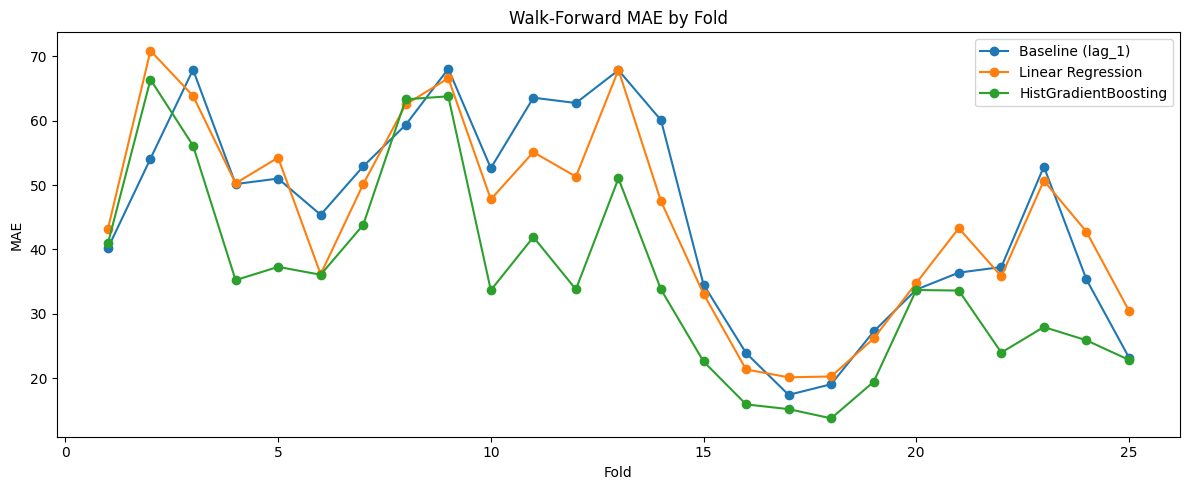

In [50]:
plt.figure(figsize=(12, 5))
plt.plot(backtest_results["fold"], backtest_results["baseline_mae"], marker="o", label="Baseline (lag_1)")
plt.plot(backtest_results["fold"], backtest_results["lr_mae"], marker="o", label="Linear Regression")
plt.plot(backtest_results["fold"], backtest_results["hgb_mae"], marker="o", label="HistGradientBoosting")
plt.title("Walk-Forward MAE by Fold")
plt.xlabel("Fold")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
winner_per_fold = []

for _, row in backtest_results.iterrows():
    maes = {
        "Baseline (lag_1)": row["baseline_mae"],
        "Linear Regression": row["lr_mae"],
        "HistGradientBoosting": row["hgb_mae"],
    }
    winner = min(maes, key=maes.get)
    winner_per_fold.append(winner)

winner_counts = pd.Series(winner_per_fold).value_counts()
print("===== FOLD WIN COUNTS =====")
print(winner_counts)

===== FOLD WIN COUNTS =====
HistGradientBoosting    22
Baseline (lag_1)         3
Name: count, dtype: int64


#### Using expanding-window walk-forward backtesting, HistGradientBoosting delivered the best overall 1-hour-ahead forecasting performance for France electricity prices, outperforming both a naive persistence baseline and linear regression on average across folds, although the naive baseline remained competitive in a small number of specific market regimes.

# Now we make the final prediction dataframe and dashboard-ready export

In [52]:
# Final feature set
feature_cols = [
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_mean_24",
    "rolling_std_24",
    "rolling_mean_168",
    "rolling_std_168",
]

target_col = "target_t_plus_1"

# Retrain final model on all available modeled data
final_hgb_model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_iter=300,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42
)

final_hgb_model.fit(model_df[feature_cols], model_df[target_col])

# Generate predictions on all available rows
model_df = model_df.copy()
model_df["hgb_prediction"] = final_hgb_model.predict(model_df[feature_cols])
model_df["abs_error"] = (model_df[target_col] - model_df["hgb_prediction"]).abs()
model_df["squared_error"] = (model_df[target_col] - model_df["hgb_prediction"]) ** 2

# Dashboard-ready output
predictions_df = model_df[[
    "timestamp",
    "price",
    "target_t_plus_1",
    "hgb_prediction",
    "abs_error",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_mean_24",
    "rolling_std_24",
    "rolling_mean_168",
    "rolling_std_168",
]].copy()

print(predictions_df.head())
print(predictions_df.tail())

# Save for dashboard / later API use
predictions_df.to_csv("france_price_predictions.csv", index=False)

# Compact metrics summary
metrics_summary = pd.DataFrame([{
    "model": "HistGradientBoosting",
    "walk_forward_avg_mae": 35.690110,
    "walk_forward_avg_rmse": 47.597025,
    "single_test_mae": 37.498524,
    "single_test_rmse": 50.341898
}])

metrics_summary.to_csv("model_metrics_summary.csv", index=False)

print("\nSaved files:")
print("- france_price_predictions.csv")
print("- model_metrics_summary.csv")

            timestamp   price  target_t_plus_1  hgb_prediction  abs_error  \
0 2022-01-08 00:00:00  184.96           162.79      187.092122  24.302122   
1 2022-01-08 01:00:00  162.79           166.00      171.966304   5.966304   
2 2022-01-08 02:00:00  166.00           161.63      151.130729  10.499271   
3 2022-01-08 03:00:00  161.63           160.00      151.105760   8.894240   
4 2022-01-08 04:00:00  160.00           154.30      163.343137   9.043137   

   hour  day_of_week  month  is_weekend   lag_1  lag_24  lag_168  \
0     0            5      1           1  205.74  213.47    89.06   
1     1            5      1           1  184.96  189.00    78.48   
2     2            5      1           1  162.79  180.00    85.16   
3     3            5      1           1  166.00  164.90    50.00   
4     4            5      1           1  161.63  162.80    37.67   

   rolling_mean_24  rolling_std_24  rolling_mean_168  rolling_std_168  
0       215.915000       31.723475        144.550833    